In [1]:
import json, polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"; F = ROOT / "reports" / "figures"
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_tbl_width_chars(200)
def show(p): display(Image(filename=str(p)))
def tab(p, cols=None):
    d = pl.read_csv(p); return d.select(cols) if cols else d

# 03 · Statistical alpha tests (development period)
HAC (Newey-West, 2h lags) regressions of h-minute forward returns on standardised signals, a non-overlapping re-check, controls, decile spreads with a 5-day moving-block bootstrap, and Holm/BH adjustment over the whole family of tests.

In [2]:
tab(T / 'stats_univariate_predictive.csv', ['signal','h','pearson','beta_bps_per_sd','t_hac','p_hac','p_holm','p_bh','t_nonoverlap'])

signal,h,pearson,beta_bps_per_sd,t_hac,p_hac,p_holm,p_bh,t_nonoverlap
str,i64,f64,f64,f64,f64,f64,f64,f64
"""ofi_1""",5,-0.007537,-0.145724,-9.739133,2.0530e-22,7.3908e-21,7.3908e-21,-1.986394
"""ofi_1""",15,-0.005158,-0.16963,-5.989588,2.1037e-9,7.1527e-8,2.5245e-8,-1.093737
"""ofi_1""",30,-0.004181,-0.193671,-4.765333,0.000002,0.000062,0.000017,-2.538873
"""ofi_1""",60,-0.00363,-0.236916,-4.015025,0.000059,0.001843,0.000357,-1.065912
"""ofi_5""",5,-0.008818,-0.1705,-6.939561,3.9332e-12,1.3766e-10,7.0797e-11,-3.630769
"""ofi_5""",15,-0.006089,-0.200239,-3.818529,0.000134,0.004028,0.00069,-0.908182
"""ofi_5""",30,-0.004837,-0.224074,-2.89747,0.003762,0.105332,0.015047,0.114509
"""ofi_5""",60,-0.003988,-0.260285,-2.33621,0.01948,0.467527,0.053945,0.327479
"""ofi_15""",5,-0.004213,-0.081448,-2.820363,0.004797,0.129517,0.017269,-1.513167


## Does the signal survive momentum, volatility and volume controls?

In [3]:
tab(T / 'stats_with_controls.csv')

signal,h,n,beta_signal_bps_per_sd,t_signal,p_signal,t_ret_15,t_ret_60,t_vol_60,t_volume_z_1440,r2,p_holm
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ofi_15""",5,1360011,0.100106,1.296799,0.1947,-2.232004,-0.244695,1.856022,-0.507496,0.000431,1.0
"""ofi_15""",15,1360011,-0.034386,-0.249606,0.802892,-0.64578,-0.456722,2.22402,-1.313195,0.000359,1.0
"""ofi_15""",30,1360011,-0.171749,-0.969224,0.332434,-0.121963,-0.644302,2.258042,-1.923924,0.000568,1.0
"""ofi_15""",60,1360011,0.044188,0.176255,0.860094,-0.890244,-0.410008,2.417163,-2.709764,0.00097,1.0
"""ofi_1""",5,1359968,-0.112362,-5.873703,4.2617e-9,-2.303618,-0.390996,1.854494,-0.513135,0.000444,6.8187e-8
"""ofi_1""",15,1359968,-0.146946,-4.37363,0.000012,-0.794349,-0.477038,2.227917,-1.342056,0.000378,0.000183
"""ofi_1""",30,1359968,-0.178108,-3.986591,0.000067,-0.376144,-0.63314,2.262435,-1.974218,0.000575,0.000938
"""ofi_1""",60,1359968,-0.198281,-3.263699,0.0011,-0.936417,-0.426489,2.429786,-2.818096,0.00099,0.014296
"""obi_1pct""",5,1306145,0.056623,0.895621,0.370455,-2.138977,-0.01617,1.823776,-0.416728,0.000408,1.0


## Decile analysis

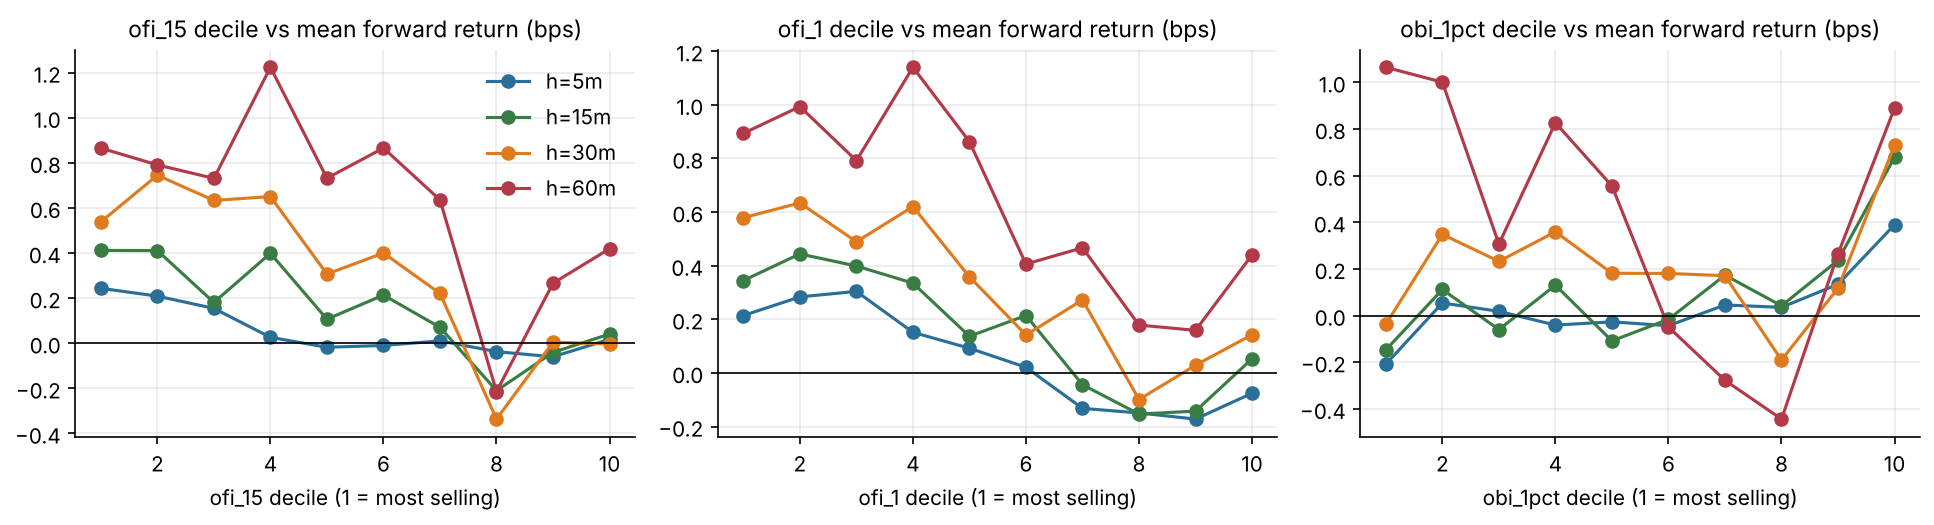

signal,h,spread_bps,boot_se_bps,ci95_lo_bps,ci95_hi_bps,p_value,n_days,decile_monotonicity_spearman,p_holm
str,i64,f64,f64,f64,f64,f64,i64,f64,f64
"""ofi_15""",5,-0.226121,0.120093,-0.456373,0.015981,0.059716,945,-0.769697,0.418012
"""ofi_15""",15,-0.370945,0.315589,-1.00876,0.293722,0.239833,945,-0.890909,1.0
"""ofi_15""",30,-0.541764,0.508471,-1.499754,0.339233,0.28666,945,-0.866667,1.0
"""ofi_15""",60,-0.446367,0.63893,-1.66687,0.727226,0.484792,945,-0.69697,1.0
"""ofi_1""",5,-0.28996,0.063168,-0.413366,-0.172668,0.000004,945,-0.878788,0.000053
"""ofi_1""",15,-0.291962,0.101372,-0.469032,-0.087889,0.003975,945,-0.866667,0.039754
"""ofi_1""",30,-0.436561,0.158322,-0.710153,-0.114831,0.005826,945,-0.830303,0.052434
"""ofi_1""",60,-0.453323,0.220162,-0.898147,-0.061502,0.03949,945,-0.793939,0.31592
"""obi_1pct""",5,0.597558,0.170894,0.28123,0.93241,0.000471,913,0.624242,0.005182


In [4]:
show(F / 'stats/decile_forward_returns.png'); tab(T / 'stats_decile_spreads.csv')

## Event study: extreme order flow

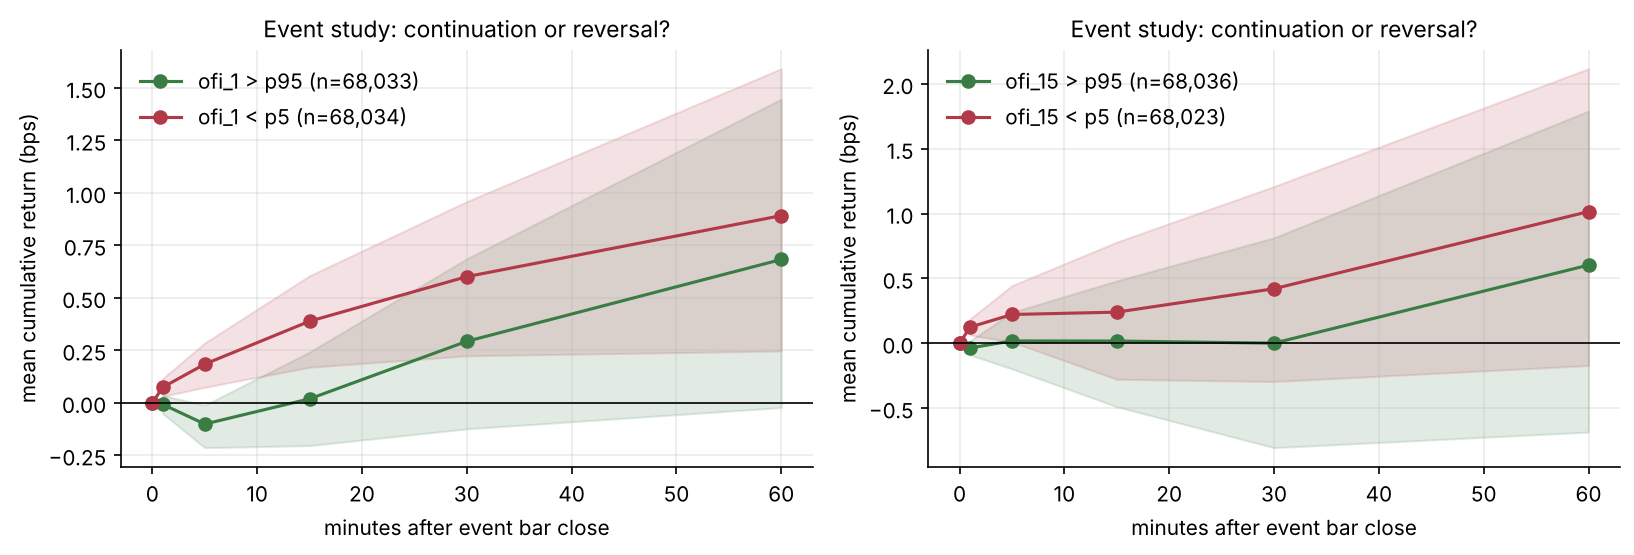

event,threshold,n_events,event_bar_ret_bps,ret_1m_bps,ci_lo_1m,ci_hi_1m,abs_move_ratio_1m,ret_5m_bps,ci_lo_5m,…,ci_hi_15m,abs_move_ratio_15m,ret_30m_bps,ci_lo_30m,ci_hi_30m,abs_move_ratio_30m,ret_60m_bps,ci_lo_60m,ci_hi_60m,abs_move_ratio_60m
str,f64,i64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ofi_1 > p95""",0.593538,68033,5.398439,-0.00785,-0.051423,0.034373,0.653436,-0.101481,-0.214162,…,0.241865,0.663939,0.292758,-0.124334,0.686034,0.676665,0.682749,-0.022925,1.446908,0.691654
"""ofi_1 < p5""",-0.602675,68034,-5.34856,0.073917,0.030491,0.115893,0.657684,0.184034,0.073802,…,0.605403,0.670684,0.600921,0.223691,0.958829,0.68437,0.89171,0.246771,1.591982,0.699381
"""ofi_15 > p95""",0.242718,68036,2.016484,-0.035824,-0.089435,0.018014,0.794648,0.018091,-0.197245,…,0.481464,0.760231,0.001037,-0.805253,0.813242,0.755945,0.602797,-0.684626,1.790818,0.754224
"""ofi_15 < p5""",-0.258063,68023,-2.141174,0.124626,0.063226,0.187488,0.838083,0.221976,0.010024,…,0.780426,0.801129,0.420512,-0.295096,1.20939,0.795633,1.015314,-0.171673,2.117536,0.791373


In [5]:
show(F / 'stats/event_study.png'); tab(T / 'stats_event_study.csv')

## Stability across quarters

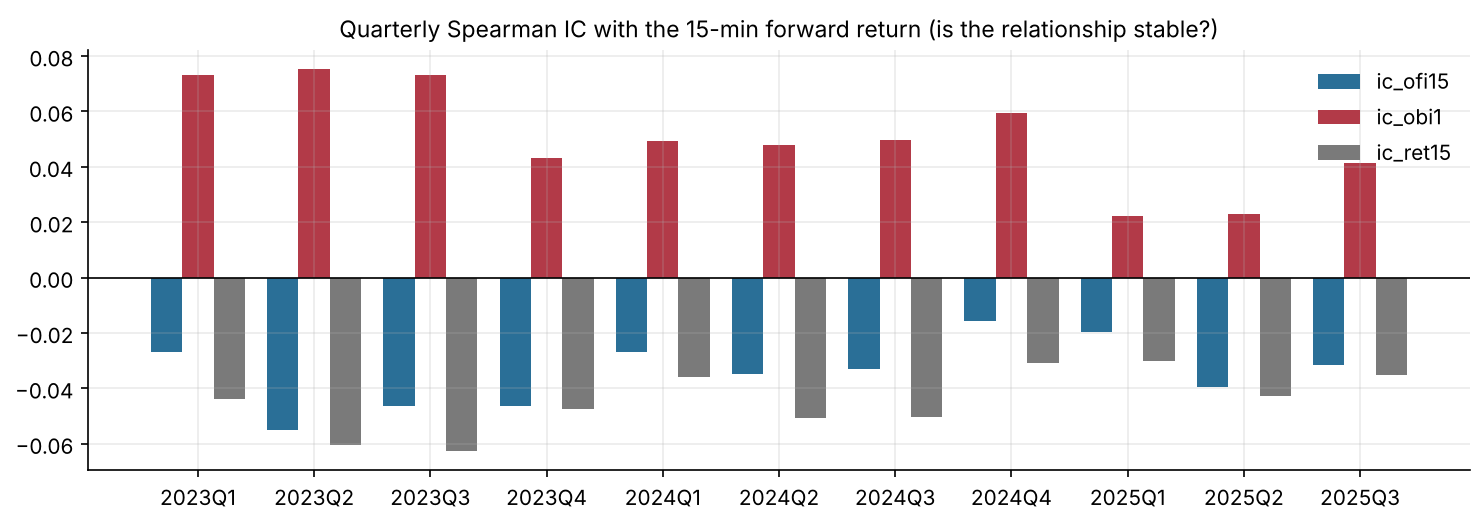

qtr,ic_ofi15,ic_obi1,ic_ret15,n
str,f64,f64,f64,i64
"""2023Q1""",-0.026714,0.07317,-0.043712,44640
"""2023Q2""",-0.054963,0.075415,-0.060367,131040
"""2023Q3""",-0.046491,0.07304,-0.062688,132480
"""2023Q4""",-0.046295,0.043247,-0.047622,132480
"""2024Q1""",-0.027007,0.049316,-0.03593,131040
"""2024Q2""",-0.034834,0.047733,-0.050855,131040
"""2024Q3""",-0.033208,0.049607,-0.050279,132480
"""2024Q4""",-0.015823,0.059498,-0.030966,132480
"""2025Q1""",-0.019692,0.022362,-0.030183,129600


In [6]:
show(F / 'stats/quarterly_ic.png'); tab(T / 'stats_quarterly_rank_ic.csv')